In [ ]:
# Instalar pacotes necessários
!pip install opencv-python opencv-python-headless numpy matplotlib gdown

import numpy as np
import cv2
from matplotlib import pyplot as plt
import gdown

# Baixar as imagens do Google Drive usando o gdown
gdown.download('https://drive.google.com/uc?id=1Lu4J0fcsiB9gqhVyN1-puVl6j2HgMHFo', 'image_l.png', quiet=False)
gdown.download('https://drive.google.com/uc?id=1Jdfpud-sSIgnn6NNRP7UP3y3v7q2wvtU', 'image_r.png', quiet=False)

# Carregar as imagens esquerda e direita em escala de cinza
imgLeft = cv2.imread('image_l.png', 0)
imgRight = cv2.imread('image_r.png', 0)

# Verificar se as imagens foram carregadas corretamente
if imgLeft is None:
    print("Erro ao carregar 'image_l.png'. Verifique o caminho do arquivo.")
    exit()

if imgRight is None:
    print("Erro ao carregar 'image_r.png'. Verifique o caminho do arquivo.")
    exit()

# Detectar os keypoints e computar os descritores usando SIFT
sift = cv2.SIFT_create()  # Use esta linha ao invés de 'cv2.xfeatures2d.SIFT_create()'
keyPointsLeft, descriptorsLeft = sift.detectAndCompute(imgLeft, None)
keyPointsRight, descriptorsRight = sift.detectAndCompute(imgRight, None)

# Criar o objeto FLANN matcher
FLANN_INDEX_KDTREE = 0
indexParams = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
searchParams = dict(checks=50)
flann = cv2.FlannBasedMatcher(indexParams, searchParams)

# Encontrar correspondências com KNN
matches = flann.knnMatch(descriptorsLeft, descriptorsRight, k=2)

# Aplicar o teste da razão (ratio test)
goodMatches = []
ptsLeft = []
ptsRight = []

for m, n in matches:
    if m.distance < 0.8 * n.distance:
        goodMatches.append([m])
        ptsLeft.append(keyPointsLeft[m.queryIdx].pt)
        ptsRight.append(keyPointsRight[m.trainIdx].pt)

ptsLeft = np.int32(ptsLeft)
ptsRight = np.int32(ptsRight)
F, mask = cv2.findFundamentalMat(ptsLeft,
                                 ptsRight,
                                 cv2.FM_LMEDS)

# Selecionar apenas os pontos inliers
ptsLeft = ptsLeft[mask.ravel() == 1]
ptsRight = ptsRight[mask.ravel() == 1]

def drawlines(img1, img2, lines, pts1, pts2):
    r, c = img1.shape
    img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

    for r, pt1, pt2 in zip(lines, pts1, pts2):
        color = tuple(np.random.randint(0, 255, 3).tolist())
        x0, y0 = map(int, [0, -r[2] / r[1]])
        x1, y1 = map(int, [c, -(r[2] + r[0] * c) / r[1]])
        img1 = cv2.line(img1, (x0, y0), (x1, y1), color, 1)
        img1 = cv2.circle(img1, tuple(pt1), 5, color, -1)
        img2 = cv2.circle(img2, tuple(pt2), 5, color, -1)
    return img1, img2

# Encontrar epilinhas correspondentes aos pontos na imagem direita
linesLeft = cv2.computeCorrespondEpilines(ptsRight.reshape(-1, 1, 2), 2, F)
linesLeft = linesLeft.reshape(-1, 3)
img5, img6 = drawlines(imgLeft, imgRight, linesLeft, ptsLeft, ptsRight)

# Encontrar epilinhas correspondentes aos pontos na imagem esquerda
linesRight = cv2.computeCorrespondEpilines(ptsLeft.reshape(-1, 1, 2), 1, F)
linesRight = linesRight.reshape(-1, 3)
img3, img4 = drawlines(imgRight, imgLeft, linesRight, ptsRight, ptsLeft)


# Certifique-se de que ptsLeft e ptsRight são float32
ptsLeft = np.float32(ptsLeft)
ptsRight = np.float32(ptsRight)

if F is None:
    print("Erro: a matriz fundamental não foi calculada corretamente.")
    exit()

K = np.array([[1000, 0, 640],
              [0, 980, 360],
              [0, 0, 1]], dtype=float)

# 1. Calcule a matriz essencial
E = K.T @ F @ K

# 2. Recupere a pose da câmera
_, R, t, mask_pose = cv2.recoverPose(E, ptsLeft, ptsRight, K)
if R is None or t is None:
    print("Erro ao recuperar a pose da câmera.")
    exit()

# 3. Monte as matrizes de projeção e triangule para obter pontos 3D
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = K @ np.hstack((R, t))

# Triangular e normalizar os pontos 3D
points_3D = cv2.triangulatePoints(P1, P2, ptsLeft.T, ptsRight.T).astype(np.float32)

# Verificar se o 4º componente dos pontos 3D não é zero
if np.all(points_3D[3] != 0):  # Verifica se todos os valores do 4º componente são diferentes de zero
    points_3D /= points_3D[3]  # Normalização
else:
    print("Erro: pontos 3D com 4º componente zero.")
    exit()

print("Deu certo!")

Downloading...
From: https://drive.google.com/uc?id=1Lu4J0fcsiB9gqhVyN1-puVl6j2HgMHFo
To: /content/image_l.png
100%|██████████| 67.0k/67.0k [00:00<00:00, 72.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Jdfpud-sSIgnn6NNRP7UP3y3v7q2wvtU
To: /content/image_r.png
100%|██████████| 61.5k/61.5k [00:00<00:00, 57.9MB/s]


Deu certo!


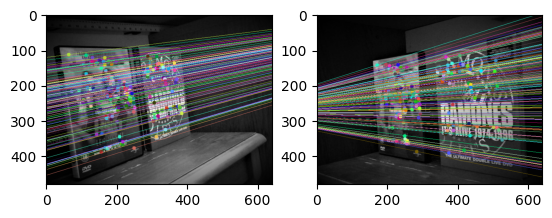

In [ ]:

# Exibir as imagens com as linhas epipolares
plt.subplot(121), plt.imshow(img5)
plt.subplot(122), plt.imshow(img3)
plt.show()

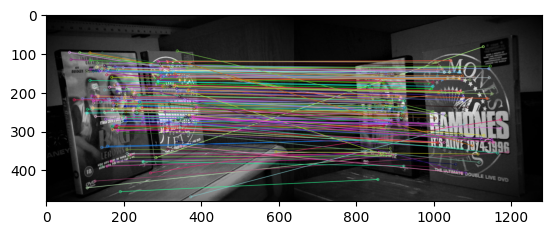

In [ ]:

# Exibir os resultados dos keypoints
imgMatches = cv2.drawMatchesKnn(imgLeft, keyPointsLeft, imgRight, keyPointsRight, goodMatches, None, flags=2)
plt.imshow(imgMatches)
plt.show()

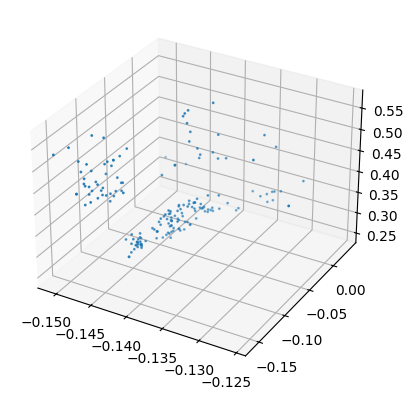

In [ ]:

# 4. Visualize a nuvem de pontos 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_3D[0], points_3D[1], points_3D[2], s=1)
plt.show()

